# Shapash - Counterfactual Business Scenarios

This notebook shows how to compare business action scenarios for an at-risk customer and identify the best lever using local explanations.

In [ ]:
import numpy as np
import pandas as pd

from category_encoders import one_hot
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

from shapash import SmartExplainer

## 1. Build a synthetic default target

We generate a synthetic consumer credit portfolio to illustrate default-risk scoring and counterfactual business scenarios.
- `1`: borrower likely to default
- `0`: borrower unlikely to default

In [2]:
rng = np.random.default_rng(42)
n_samples = 1800

df = pd.DataFrame(
    {
        "Age": rng.integers(21, 71, n_samples),
        "Income": rng.normal(55000, 18000, n_samples).clip(18000, 160000).round(0),
        "LoanAmount": rng.normal(25000, 12000, n_samples).clip(2000, 90000).round(0),
        "CreditScore": rng.normal(680, 55, n_samples).clip(480, 840).round(0),
        "EmploymentYears": rng.integers(0, 31, n_samples),
        "NumLatePayments": rng.poisson(0.9, n_samples).clip(0, 8),
        "DTI": rng.normal(0.32, 0.12, n_samples).clip(0.05, 0.8).round(3),
        "HomeOwner": rng.choice(["Yes", "No"], n_samples, p=[0.62, 0.38]),
        "MaritalStatus": rng.choice(["Single", "Married", "Divorced"], n_samples, p=[0.36, 0.52, 0.12]),
        "LoanPurpose": rng.choice(
            ["Debt consolidation", "Car purchase", "Home improvement", "Medical", "Education"],
            n_samples,
            p=[0.34, 0.19, 0.21, 0.12, 0.14],
        ),
    }
)

homeowner_flag = (df["HomeOwner"] == "Yes").astype(float)
purpose_risk = df["LoanPurpose"].map(
    {
        "Debt consolidation": 0.40,
        "Car purchase": 0.10,
        "Home improvement": 0.08,
        "Medical": 0.22,
        "Education": 0.06,
    }
)

logit = (
    -4.0
    + 3.0 * (df["LoanAmount"] / df["Income"]).astype(float)
    + 3.6 * df["DTI"].astype(float)
    + 0.018 * (700 - df["CreditScore"]).astype(float)
    + 0.65 * df["NumLatePayments"].astype(float)
    - 0.10 * df["EmploymentYears"].astype(float)
    - 0.45 * homeowner_flag
    + purpose_risk.astype(float)
    + rng.normal(0, 0.5, n_samples)
 )

default_probability = 1 / (1 + np.exp(-logit))
df["Default"] = rng.binomial(1, default_probability)

features = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "EmploymentYears",
    "NumLatePayments",
    "DTI",
    "HomeOwner",
    "MaritalStatus",
    "LoanPurpose",
]
target_name = "Default"

X_raw = df[features]
y = df[[target_name]]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.25, random_state=42, stratify=y
)

encoder = one_hot.OneHotEncoder(df, cols=["HomeOwner", "MaritalStatus", "LoanPurpose"])
X_train = encoder.fit_transform(X_train_raw)
X_test = encoder.transform(X_test_raw)

clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train.iloc[:, 0])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [3]:
def cls_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

pred_test = clf.predict(X_test)
metrics = pd.DataFrame([cls_metrics(y_test.iloc[:, 0], pred_test)], index=["test"])
metrics

,accuracy,precision,recall,f1
test,0.833333,0.734375,0.447619,0.556213


## 2. Explain baseline model

INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x108dde000>


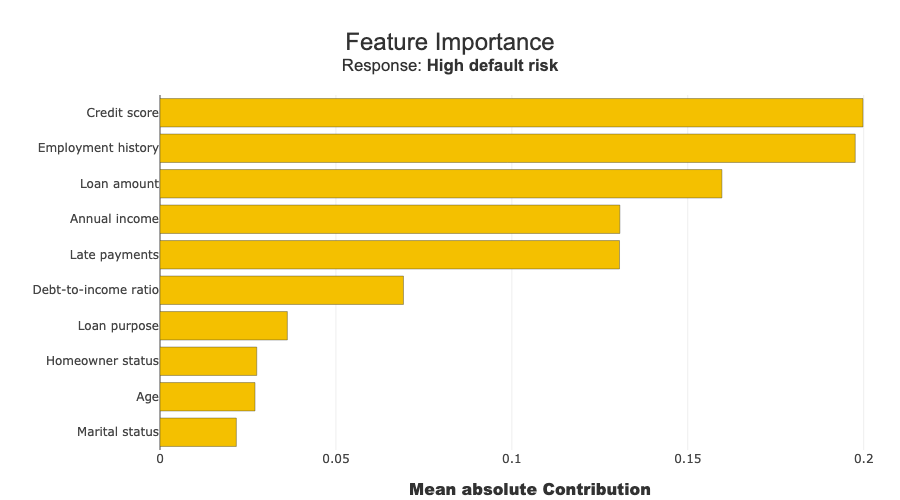

In [4]:
feature_dict = {
    "Age": "Age",
    "Income": "Annual income",
    "LoanAmount": "Loan amount",
    "CreditScore": "Credit score",
    "EmploymentYears": "Employment history",
    "NumLatePayments": "Late payments",
    "DTI": "Debt-to-income ratio",
    "HomeOwner": "Homeowner status",
    "MaritalStatus": "Marital status",
    "LoanPurpose": "Loan purpose",
}

xpl = SmartExplainer(
    model=clf,
    preprocessing=encoder,
    features_dict=feature_dict,
    label_dict={0: "Low default risk", 1: "High default risk"},
    title_story="Default risk scenario analysis",
)

y_pred_test_df = pd.DataFrame(clf.predict(X_test), index=X_test.index, columns=[target_name])

xpl.compile(
    x=X_test,
    y_pred=y_pred_test_df,
    y_target=y_test,
    additional_data=df.loc[X_test.index, [
        "Age",
        "Income",
        "LoanAmount",
        "CreditScore",
        "EmploymentYears",
        "NumLatePayments",
        "DTI",
        "HomeOwner",
        "MaritalStatus",
        "LoanPurpose",
    ]],
)

xpl.plot.features_importance()

## 3. Pick one high-risk borrower

In [5]:
proba_test = pd.Series(clf.predict_proba(X_test)[:, 1], index=X_test_raw.index)
customer_idx = proba_test.sort_values(ascending=False).index[0]

base_customer = X_test_raw.loc[[customer_idx]].copy()
base_risk = float(clf.predict_proba(encoder.transform(base_customer))[:, 1][0])

base_customer.assign(default_probability=base_risk).T

,1705
Age,63
Income,58292.0
LoanAmount,46258.0
CreditScore,614.0
EmploymentYears,2
NumLatePayments,1
DTI,0.248
HomeOwner,Yes
MaritalStatus,Single
LoanPurpose,Car purchase


## 4. Define business scenarios (counterfactuals)

Simplified action rules for the demo:
- `loan_reduction`: reduce `LoanAmount` by 20%
- `credit_repair`: improve `CreditScore` and reduce recent late payments
- `income_growth`: increase `Income` and lower `DTI`
- `full_restructure`: combine all three actions

In [6]:
def apply_scenario(base_row, scenario_name):
    row = base_row.copy()
    if scenario_name == "loan_reduction":
        row.loc[:, "LoanAmount"] = np.maximum(1000.0, row["LoanAmount"].fillna(25000).iloc[0] * 0.8)
        row.loc[:, "DTI"] = np.maximum(0.05, row["DTI"].fillna(0.3).iloc[0] * 0.9)
    elif scenario_name == "credit_repair":
        row.loc[:, "CreditScore"] = min(850.0, row["CreditScore"].fillna(680).iloc[0] + 40)
        row.loc[:, "NumLatePayments"] = max(0, int(row["NumLatePayments"].fillna(0).iloc[0]) - 1)
    elif scenario_name == "income_growth":
        row.loc[:, "Income"] = row["Income"].fillna(55000).iloc[0] * 1.2
        row.loc[:, "DTI"] = np.maximum(0.05, row["DTI"].fillna(0.3).iloc[0] * 0.85)
    elif scenario_name == "full_restructure":
        row.loc[:, "LoanAmount"] = np.maximum(1000.0, row["LoanAmount"].fillna(25000).iloc[0] * 0.8)
        row.loc[:, "CreditScore"] = min(850.0, row["CreditScore"].fillna(680).iloc[0] + 40)
        row.loc[:, "NumLatePayments"] = max(0, int(row["NumLatePayments"].fillna(0).iloc[0]) - 1)
        row.loc[:, "Income"] = row["Income"].fillna(55000).iloc[0] * 1.2
        row.loc[:, "DTI"] = np.maximum(0.05, row["DTI"].fillna(0.3).iloc[0] * 0.8)
    else:
        raise ValueError(f"Unknown scenario: {scenario_name}")
    return row

scenario_names = ["loan_reduction", "credit_repair", "income_growth", "full_restructure"]
scenario_rows = []

for name in scenario_names:
    row = apply_scenario(base_customer, name)
    row.index = [name]
    scenario_rows.append(row)

scenario_df = pd.concat(scenario_rows, axis=0)
scenario_proba = clf.predict_proba(encoder.transform(scenario_df))[:, 1]

result = pd.DataFrame(
    {
        "scenario": scenario_names,
        "baseline_risk": [base_risk] * len(scenario_names),
        "scenario_risk": scenario_proba,
        "risk_delta": scenario_proba - base_risk,
    }
)
result.sort_values("risk_delta")

,scenario,baseline_risk,scenario_risk,risk_delta
3,full_restructure,0.843333,0.436667,-0.406667
0,loan_reduction,0.843333,0.700000,-0.143333
2,income_growth,0.843333,0.713333,-0.130000
1,credit_repair,0.843333,0.740000,-0.103333


## 5. Explain baseline vs best scenario

INFO: Shap explainer type - <shap.explainers._tree.TreeExplainer object at 0x11ea85dc0>


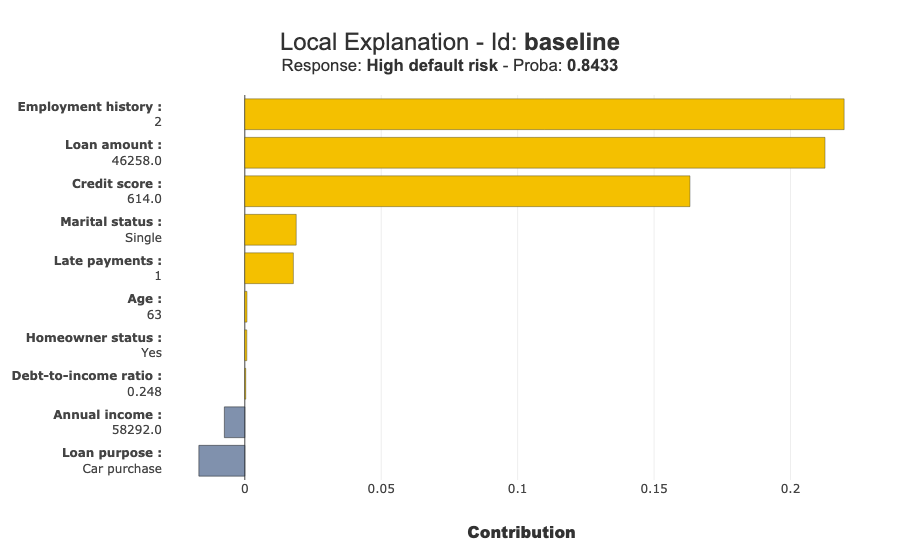

In [7]:
best_scenario_name = result.sort_values("risk_delta").iloc[0]["scenario"]
best_row = scenario_df.loc[[best_scenario_name]].copy()

compare_rows = pd.concat([base_customer, best_row], axis=0)
compare_rows.index = ["baseline", "best_scenario"]

compare_encoded = encoder.transform(compare_rows)
compare_pred_df = pd.DataFrame(
    clf.predict(compare_encoded),
    index=compare_rows.index,
    columns=[target_name],
)

xpl_compare = SmartExplainer(
    model=clf,
    preprocessing=encoder,
    features_dict=feature_dict,
    label_dict={0: "Low default risk", 1: "High default risk"},
    title_story="Counterfactual comparison",
)
xpl_compare.compile(x=compare_encoded, y_pred=compare_pred_df, additional_data=compare_rows)

xpl_compare.plot.local_plot(index="baseline")

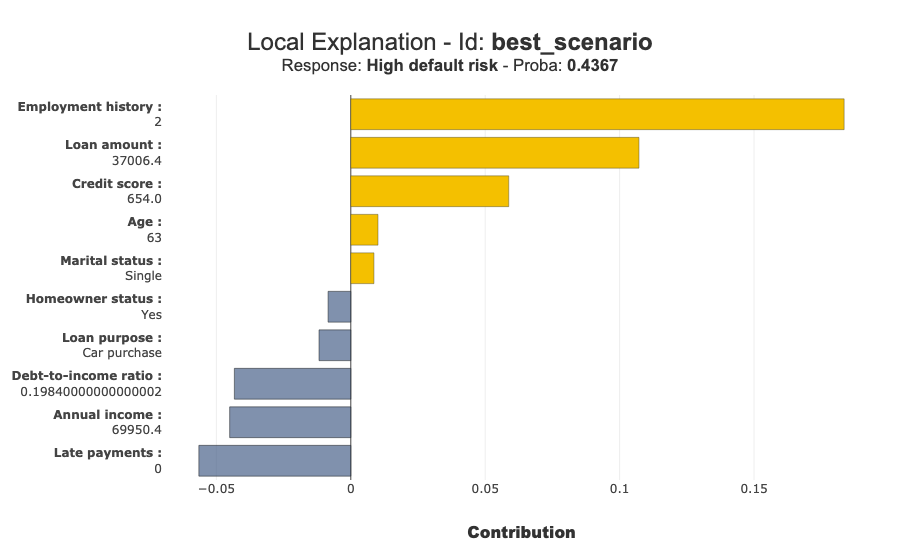

In [8]:
xpl_compare.plot.local_plot(index="best_scenario")

## 6. Decision checklist

- Rank scenarios by impact and business cost.
- Exclude non-actionable or sensitive variables.
- Verify the plausibility of the proposed counterfactuals.
- Monitor the effects actually observed after deployment.